In [2]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

In [101]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils
import merger_tree_tools as mgt

In [102]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
def q_pos(mbID, npart=4320, BoxSize=500, mtng=False, idstart=0):
    
    if mtng:
        mbID[np.where(mbID>=1)] -= 20155392000
        mbID[np.where(mbID<1)] += 80621568000

    q = np.zeros(mbID.shape + (3,), dtype=np.float32)

    q[..., 0] = (mbID - idstart) // npart**2
    q[..., 1] = ( (mbID - idstart) // npart) % npart
    q[..., 2] = (mbID - idstart) % npart

    # normalize correctly
    q *= (BoxSize / npart)

    return q

### Load the Zoom

In [325]:
base = "/cosmos_storage/data_sharing/MN5_resims/1pmbin_2160_legacy/fiducial/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 100

zoom = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='gadget4_hdf5', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, numpart=4320**3)

2024-08-22 16:18:47,376 bacco.sims : Initialising simulation Default
2024-08-22 16:18:47,377 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/1pmbin_2160_legacy/fiducial/hydro_output/groups_100/fof_subhalo_tab_100
2024-08-22 16:18:47,380 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/1pmbin_2160_legacy/fiducial/hydro_output/groups_100/fof_subhalo_tab_100


2024-08-22 16:18:47,387 bacco.sims : ...done in 0.0117 s


### Load the Original Sim

In [312]:
# we need this one for the indices (the saved selection is relative to this snapshot)
mtng_z0 = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)
mtng_z0.fof['halo_pos'][:,0] = (mtng_z0.fof['halo_pos'][:,0] - 125) % 500
mtng_z0.sub['pos'][:,0] = (mtng_z0.sub['pos'][:,0] - 125) % 500


mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=100)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

print(mtng.header['Redshift'])

2024-08-22 16:10:30,526 bacco.sims : Initialising simulation Default
2024-08-22 16:10:30,527 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-22 16:10:30,531 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-22 16:10:30,534 bacco.sims : ...done in 0.00786 s
2024-08-22 16:10:30,537 bacco.sims : Reading 98233510 items for GroupPos


2024-08-22 16:10:37,663 bacco.sims : Reading 90246895 items for SubhaloPos
2024-08-22 16:10:44,526 bacco.sims : Initialising simulation Default
2024-08-22 16:10:44,528 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_100/fof_subhalo_tab_100
2024-08-22 16:10:44,575 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_100/fof_subhalo_tab_100
2024-08-22 16:10:44,594 bacco.sims : ...done in 0.0678 s
2024-08-22 16:10:44,601 bacco.sims : Reading 116846005 items for GroupPos
2024-08-22 16:11:57,801 bacco.sims : Reading 124420311 items for SubhaloPos


2.789151963173933


### Cross-Match Selected Halos

In [ ]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/2160-A/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

First cross-match z=0 to other z

In [12]:
snap_0 = 264

tree = mgt.tree(snap_0=snap_0) # class object containing methods related to the merger-trees
tree.get_tree_props(final_sel)

In [313]:
idx = tree.walk_tree()

sel_z = np.zeros(len(final_sel), dtype=int)

for i in range(len(final_sel)):
    sel_z[i] = tree.group_nr[i][idx[i,264-100]]

### Now cross-match those at same redshift

In [369]:
psel = np.where(zoom.fof['halo_m200b']>0)

X1 = zoom.fof['halo_pos'][psel]
X2 = mtng.fof['halo_pos'][sel_z]

kdt = KDTree(X1, boxsize=500)
dist, ind = kdt.query(X2, k=100)
dist /= mtng.fof['halo_r200c'][sel_z, np.newaxis]

ind[np.where(dist==np.inf)] = -1

/tmp/ipykernel_84796/3490640990.py:8: RuntimeWarning: divide by zero encountered in divide
  dist /= mtng.fof['halo_r200c'][sel_z, np.newaxis]


In [370]:
M1 = 1e10 * zoom.fof['halo_m200b'][psel][ind]
M2 = 1e10 * mtng.fof['halo_m200b'][sel_z]

pos1 = np.transpose(zoom.fof['halo_pos'][psel][ind], (2,0,1))
pos2 = mtng.fof['halo_pos'][sel_z].T

vmax_1 = zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel][ind]]
vmax_2 = mtng.sub['vmax'][mtng.fof['halo_firstsub'][sel_z]]


In [377]:
def metric(m1,m2,v1,v2,dist,a,b,c):

    d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))
    d_v = np.abs(v1[...,np.newaxis]-v2)

    return dist*a + d_m*b + d_v*c


In [395]:
d = metric(M2,M1,vmax_2,vmax_1,dist,10,1,1)

xmatch = np.zeros(len(M1), dtype=int)
dmatch = np.zeros(len(M1))

for i in range(len(M1)):
    xmatch[i] = ind[i,np.where(d[i]==d[i].min())[0][0]]
    dmatch[i] = dist[i,np.where(d[i]==d[i].min())[0][0]]

/tmp/ipykernel_84796/765750559.py:3: RuntimeWarning: divide by zero encountered in log10
  d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))


/tmp/ipykernel_84796/2561833027.py:5: RuntimeWarning: divide by zero encountered in log10
  Xarr = np.log10(1e10*mtng.fof['halo_m200b'][sel_z])
/tmp/ipykernel_84796/2561833027.py:8: RuntimeWarning: divide by zero encountered in log10
  Xarr_out = np.log10(1e10*mtng.fof['halo_m200b'][sel_z][w])
/tmp/ipykernel_84796/2561833027.py:24: RuntimeWarning: divide by zero encountered in log10
  ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z]), dmatch * mtng.fof['halo_r200c'][sel_z], marker='o', color='C0', ms=1, ls='')
/tmp/ipykernel_84796/2561833027.py:24: RuntimeWarning: invalid value encountered in multiply
  ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z]), dmatch * mtng.fof['halo_r200c'][sel_z], marker='o', color='C0', ms=1, ls='')


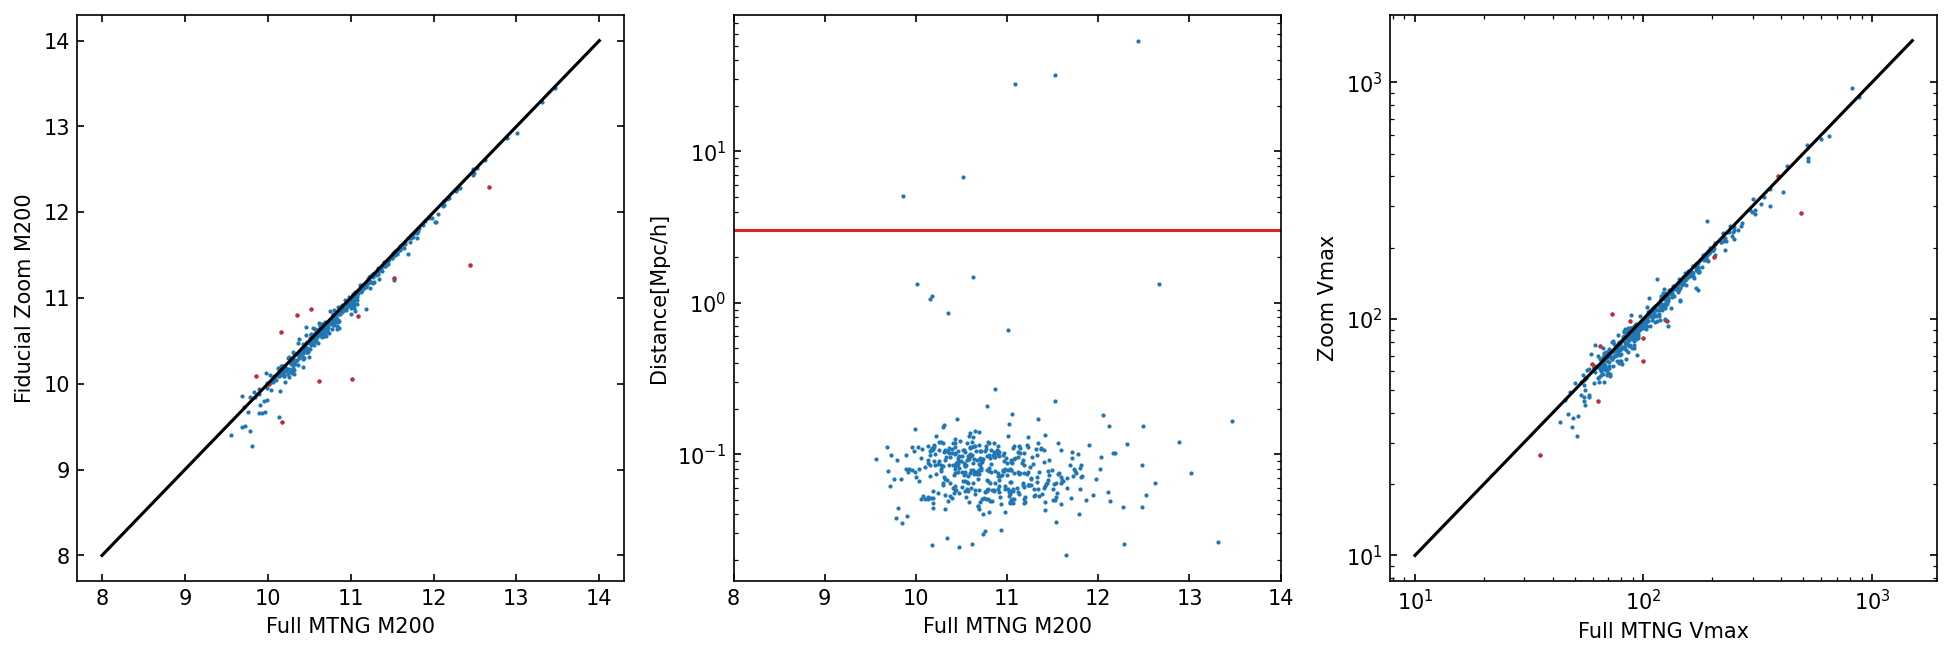

In [399]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(16,5))

w = np.where(dmatch>3)

Xarr = np.log10(1e10*mtng.fof['halo_m200b'][sel_z])
Yarr = np.log10(1e10*zoom.fof['halo_m200b'][psel][xmatch])

Xarr_out = np.log10(1e10*mtng.fof['halo_m200b'][sel_z][w])
Yarr_out = np.log10(1e10*zoom.fof['halo_m200b'][psel][xmatch][w])

ax[0].plot(Xarr, Yarr, marker='o', color='C0', ms=1, ls='')
ax[0].plot(Xarr_out, Yarr_out, marker='o', color='C3', ms=1, ls='')

ax[0].set_xlabel('Full MTNG M200')
ax[0].set_ylabel('Fiducial Zoom M200')

ax[0].plot(np.linspace(8,14,10), np.linspace(8,14,10), color='k')

#

ax[1].set_xlabel('Full MTNG M200')
ax[1].set_ylabel('Distance[Mpc/h]')

ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z]), dmatch * mtng.fof['halo_r200c'][sel_z], marker='o', color='C0', ms=1, ls='')

ax[1].set_xlim(8,14)
ax[1].axhline(3, color='C3')

ax[1].set_yscale('log')

#

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[2].set_xlabel('Full MTNG Vmax')
ax[2].set_ylabel('Zoom Vmax')

ax[2].plot(mtng.sub['vmax'][mtng.fof['halo_firstsub'][sel_z]], zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel][xmatch]], marker='o', color='C0', ms=1, ls='')
ax[2].plot(mtng.sub['vmax'][mtng.fof['halo_firstsub'][sel_z][w]], zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel][xmatch][w]], marker='o', color='C3', ms=1, ls='')

ax[2].plot(np.linspace(10,1500,100), np.linspace(10,1500,100), color='k')

#ax[2].set_xlim(4e10,3e15)


### Let's work in a specific region

We will focus on one of the zoom halos

In [8]:
center = zoom.fof['halo_pos'][250]

2024-08-19 17:25:45,619 bacco.sims : Reading 120094 items for GroupPos


In [34]:
L_p = 10
z_slab = 10
xmin = np.array([center[0]-L_p/2,center[1]-L_p/2,center[2]-z_slab/2])

shift = np.array([0,0,0]) * L_p/512 # n=0
#shift = np.array([44,50,13]) * L_p/512 # n=1
#shift = np.array([-3,50,-25]) * L_p/512 # n=2
#shift = np.array([50,65,60]) * L_p/512 # n=3
#shift = np.array([86,18,70]) * L_p/512 # n4

mtng_sel = np.where( (mtng.fof['halo_pos'][:,0]+shift[0]>(center[0]-L_p/2)) & (mtng.fof['halo_pos'][:,0]+shift[0]<(center[0]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,1]+shift[1]>(center[1]-L_p/2)) & (mtng.fof['halo_pos'][:,1]+shift[1]<(center[1]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,2]+shift[2]>(center[2]-z_slab/2)) & (mtng.fof['halo_pos'][:,2]+shift[1]<(center[2]+z_slab/2)) &\
                     (mtng.fof['halo_m200b']>1))[0]

In [35]:
zoom_sel = np.where( (zoom.dm['pos'][:,0]>(center[0]-L_p/2)) & (zoom.dm['pos'][:,0]<(center[0]+L_p/2)) &\
                     (zoom.dm['pos'][:,1]>(center[1]-L_p/2)) & (zoom.dm['pos'][:,1]<(center[1]+L_p/2)) &\
                     (zoom.dm['pos'][:,2]>(center[2]-z_slab/2)) & (zoom.dm['pos'][:,2]<(center[2]+z_slab/2)) )[0]

zoom_grid = bacco.statistics.compute_mesh(pos=zoom.dm['pos'][zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

In [36]:
#del sel_pos

shift = np.array([0,0,0]) * L_p/512 # n=0
#shift = np.array([44,50,13]) * L_p/512 # n=1
#shift = np.array([-3,50,-25]) * L_p/512 # n=2
#shift = np.array([80,35,60]) * L_p/512 # n=3
#shift = np.array([86,18,70]) * L_p/512 # n4

sel_pos = (mtng.fof['halo_pos'][mtng_sel]-xmin[np.newaxis, :]-shift[np.newaxis, :])/L_p * 512

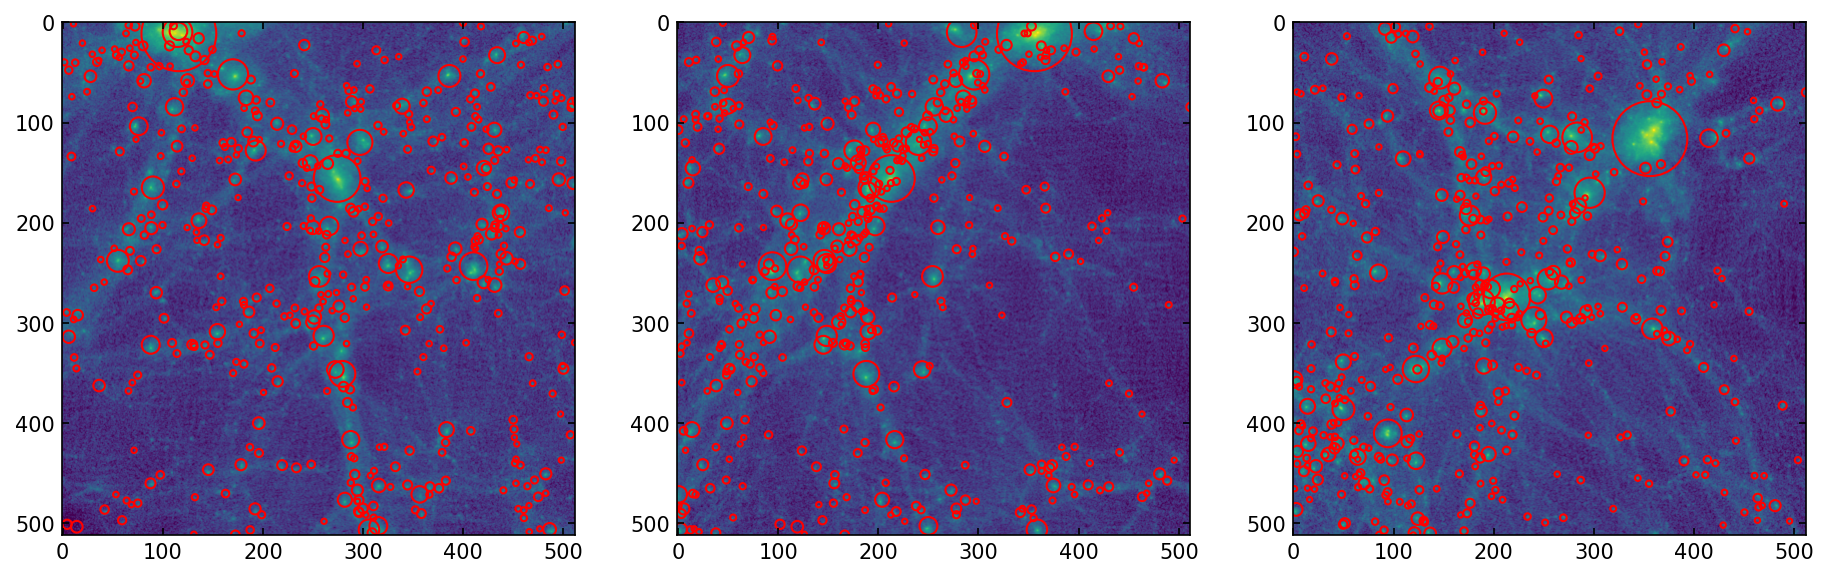

In [37]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(15,5))

ax[0].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=2)))
ax[1].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=1)))
ax[2].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=0)))

for i in range(sel_pos.shape[0]):
    circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[0].add_artist(circle)
    circle = plt.Circle((sel_pos[i,2],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[1].add_artist(circle)
    circle = plt.Circle((sel_pos[i,2],sel_pos[i,1]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[2].add_artist(circle)

#### Cross-match halos in the this region

In [44]:
psel1 = np.where(mtng.fof['halo_m200b']>0)
psel2 = np.where(zoom.fof['halo_m200b']>0)

X1 = mtng.fof['halo_pos'][psel1]
X2 = zoom.fof['halo_pos'][psel2]

kdt = KDTree(X1, boxsize=500+1e-9)
dist, ind = kdt.query(X2, k=100)

ind[np.where(dist==np.inf)] = -1

In [45]:
M1 = 1e10 * mtng.fof['halo_m200b'][psel1][ind]
M2 = 1e10 * zoom.fof['halo_m200b'][psel2]

pos1 = np.transpose(mtng.fof['halo_pos'][psel1][ind], (2,0,1))
pos2 = zoom.fof['halo_pos'][psel2].T

vmax_1 = mtng.sub['vmax'][mtng.fof['halo_firstsub'][psel1][ind]]
vmax_2 = zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel2]]

In [97]:
d = metric(M2,M1,pos2,pos1,vmax_2,vmax_1,0.51,1,1)

xmatch = np.zeros(len(M2), dtype=int)
dmatch = np.zeros(len(M2))

for i in range(len(M2)):
    xmatch[i] = ind[i,np.where(d[i]==d[i].min())[0][0]]
    dmatch[i] = dist[i,np.where(d[i]==d[i].min())[0][0]]

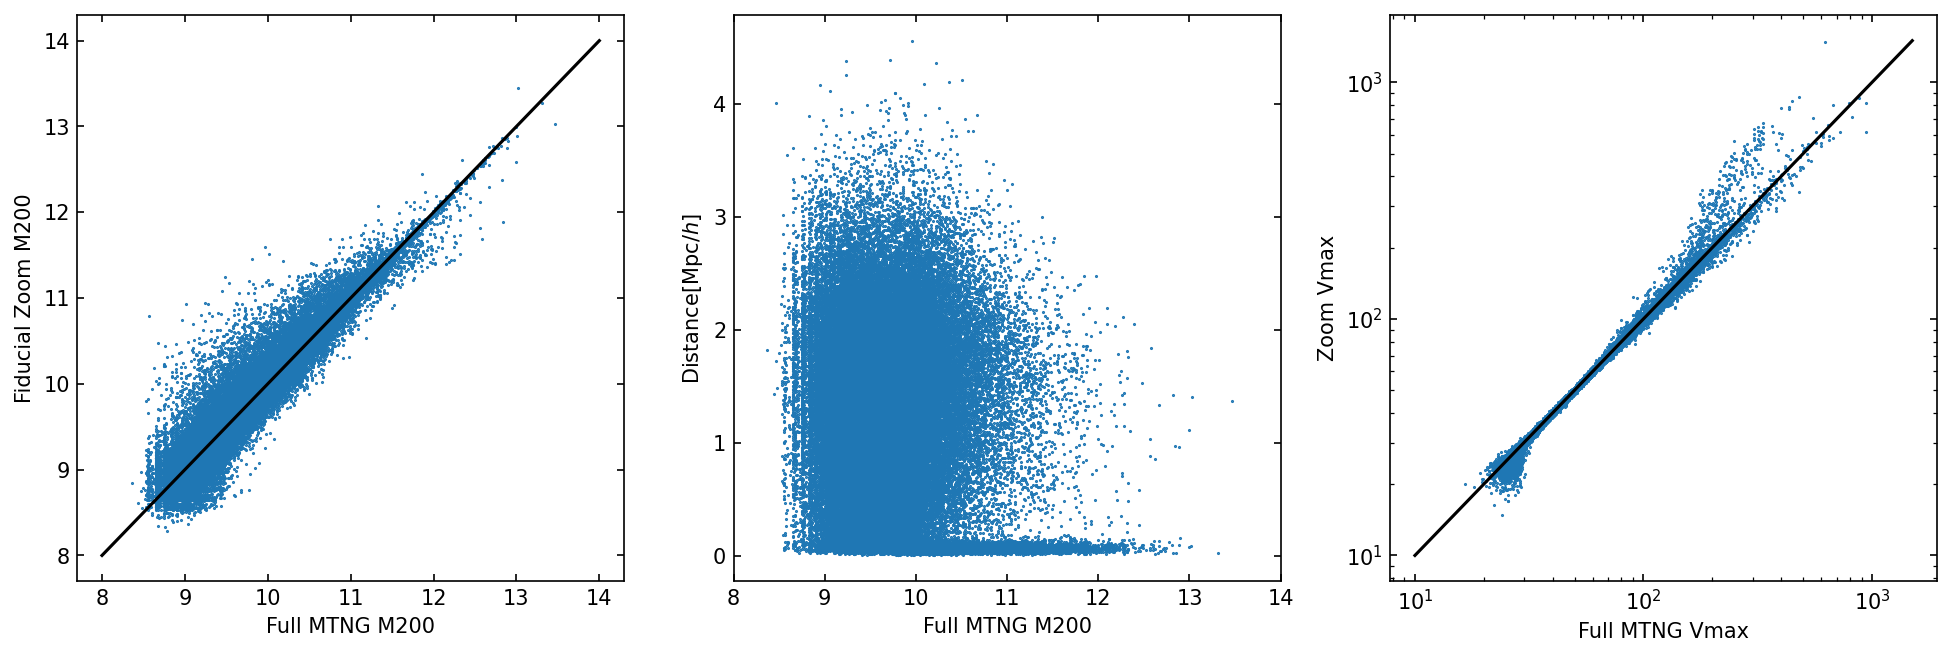

In [98]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(16,5))

Xarr = np.log10(1e10*mtng.fof['halo_m200b'][psel1][xmatch])
Yarr = np.log10(1e10*zoom.fof['halo_m200b'][psel2])

ax[0].plot(Xarr, Yarr, marker='o', color='C0', ms=0.5, ls='')

ax[0].set_xlabel('Full MTNG M200')
ax[0].set_ylabel('Fiducial Zoom M200')

ax[0].plot(np.linspace(8,14,10), np.linspace(8,14,10), color='k')

#

ax[1].set_xlabel('Full MTNG M200')
ax[1].set_ylabel('Distance$[$Mpc$/h]$')

ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][psel1][xmatch]), dmatch, marker='o', color='C0', ms=0.5, ls='')

ax[1].set_xlim(8,14)

#

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[2].set_xlabel('Full MTNG Vmax')
ax[2].set_ylabel('Zoom Vmax')

ax[2].plot(mtng.sub['vmax'][mtng.fof['halo_firstsub'][psel1][xmatch]], zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel2]], marker='o', color='C0', ms=0.5, ls='')

ax[2].plot(np.linspace(10,1500,100), np.linspace(10,1500,100), color='k')

#ax[2].set_xlim(4e10,3e15)


#### Let's get their central galaxy

In [33]:
mtng_ind_cen = np.where((mtng.sub['parent_halo']['index']==ind) &  (mtng.sub['central']==True) )
mtng_ind_sat = np.where((mtng.sub['parent_halo']['index']==ind) &  (mtng.sub['central']==False) )

/tmp/ipykernel_232797/1424730655.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  mtng_ind_cen = np.where((mtng.sub['parent_halo']['index']==ind) &  (mtng.sub['central']==True) )
2024-07-22 12:21:23,401 bacco.sims : Reading 98233510 items for halo_firstsub


2024-07-22 12:21:58,944 bacco.sims : Reading 98233510 items for GroupNsubs
/tmp/ipykernel_232797/1424730655.py:2: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  mtng_ind_sat = np.where((mtng.sub['parent_halo']['index']==ind) &  (mtng.sub['central']==False) )


In [15]:
zoom_ind_cen = np.where((zoom.sub['parent_halo']['index']==0) &  (zoom.sub['central']==True) )
zoom_ind_sat = np.where((zoom.sub['parent_halo']['index']==0) &  (zoom.sub['central']==False) )

2024-07-10 17:14:14,318 bacco.sims : Reading the host halo properties of the subhaloes
2024-07-10 17:14:14,461 bacco.sims : Reading 5188 items for halo_firstsub
2024-07-10 17:14:14,479 bacco.sims : Reading 5188 items for GroupNsubs


### Now we have to load the trees

In [18]:
snap_0 = 264
depth = 100
files = np.arange(8)
Ntrees = 80

mtng_tree = mgt.tree(snap_0=snap_0, depth=depth, Ntrees=Ntrees) # class object containing methods related to the merger-trees
mtng_lentype = mtng_tree.get_subhalo_prop_hist(sub_id=mtng_ind_cen, name='SubhaloLenType')

In [19]:
snap_0 = 9
depth = 10
Ntrees = 8

tree = mgt.tree(snap_0=snap_0, depth=depth, Ntrees=Ntrees, treebase="/cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/",\
                tree_format='arepo') # class object containing methods related to the merger-trees

lentype = tree.get_subhalo_prop_hist(sub_id=zoom_ind_cen, name='SubhaloLenType')


### Plot some properties

Text(0, 0.5, '$N$')

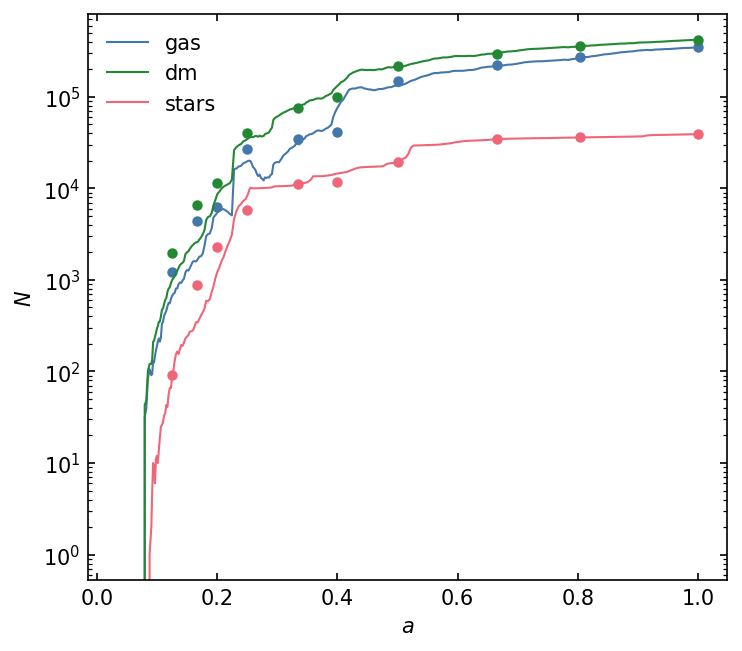

In [30]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

ax.set_yscale('log')

ax.plot(tree.expfactor[::-1], lentype[0,:], color=colors[0], ls='', marker='o', ms=4)
ax.plot(tree.expfactor[::-1], lentype[1,:], color=colors[2], ls='', marker='o', ms=4)
ax.plot(tree.expfactor[::-1], lentype[2,:], color=colors[4], ls='', marker='o', ms=4)

ax.plot(mtng_tree.expfactor[::-1], mtng_lentype[0,:], color=colors[0], lw=1, ls='-', label='gas')
ax.plot(mtng_tree.expfactor[::-1], mtng_lentype[1,:], color=colors[2], lw=1, ls='-', label='dm')
ax.plot(mtng_tree.expfactor[::-1], mtng_lentype[2,:], color=colors[4], lw=1, ls='-', label='stars')

ax.legend()

ax.set_xlabel('$a$')
ax.set_ylabel('$N$')

In [213]:
with h5py.File('/cosmos_storage/simulations/MTNG/treedata/trees.0.hdf5', 'r') as f:
    print(f['TreeHalos'].keys())

<KeysViewHDF5 ['GroupNr', 'Group_M_Crit200', 'SnapNum', 'SubhaloHalfmassRad', 'SubhaloIDMostbound', 'SubhaloLen', 'SubhaloLenType', 'SubhaloMass', 'SubhaloNr', 'SubhaloPos', 'SubhaloSpin', 'SubhaloVel', 'SubhaloVelDisp', 'SubhaloVmax', 'SubhaloVmaxRad', 'TreeDescendant', 'TreeFirstDescendant', 'TreeFirstHaloInFOFgroup', 'TreeFirstProgenitor', 'TreeID', 'TreeIndex', 'TreeMainProgenitor', 'TreeNextDescendant', 'TreeNextHaloInFOFgroup', 'TreeNextProgenitor', 'TreeProgenitor']>


In [ ]:
moi_zoom = zoom.sub['subhalo_stellar_MOI'][zoom_ind_cen[0]][0]
moi_mtng = mtng.sub['subhalo_stellar_MOI'][mtng_ind_cen[0]][0]

In [ ]:
s_zoom = np.zeros((3,3))
s_zoom[0,0] = moi_zoom[0]
s_zoom[0,1] = moi_zoom[1]
s_zoom[0,2] = moi_zoom[2]
s_zoom[1,1] = moi_zoom[3]
s_zoom[1,2] = moi_zoom[4]
s_zoom[2,2] = moi_zoom[5]
s_zoom[1,0] = s_zoom[0,1]
s_zoom[2,0] = s_zoom[0,2]
s_zoom[1,2] = s_zoom[2,1]

s_mtng = np.zeros((3,3))
s_mtng[0,0] = moi_mtng[0]
s_mtng[0,1] = moi_mtng[1]
s_mtng[0,2] = moi_mtng[2]
s_mtng[1,1] = moi_mtng[3]
s_mtng[1,2] = moi_mtng[4]
s_mtng[2,2] = moi_mtng[5]
s_mtng[1,0] = s_mtng[0,1]
s_mtng[2,0] = s_mtng[0,2]
s_mtng[1,2] = s_mtng[2,1]

In [ ]:
np.trace(s_mtng@s_zoom) / np.sqrt( np.trace(s_mtng@s_mtng) * np.trace(s_zoom@s_zoom) )

0.9299541261822105

In [ ]:
eig_zoom

(array([0.83546849, 1.01563249, 1.08112812]),
 array([[ 0.91405544, -0.00697629,  0.40552927],
        [-0.01662907, -0.99965595,  0.0202846 ],
        [ 0.40524823, -0.02528482, -0.91385696]]))

In [ ]:
eig_mtng

(array([0.58306854, 1.69148092, 1.81810906]),
 array([[ 0.93635051,  0.02128272, -0.35042083],
        [ 0.08632803,  0.95355336,  0.28858875],
        [ 0.34028692, -0.30047137,  0.89102288]]))

In [ ]:
m_sub_zoom = 1e10 * zoom.sub['MassType'][zoom_sub_sel,4][i_clean]
m_sub_mtng = 1e10 * mtng.sub['MassType'][mtng_sub_sel,4][ind[i_clean]]

Text(0, 0.5, '$M_{Zoom}$')

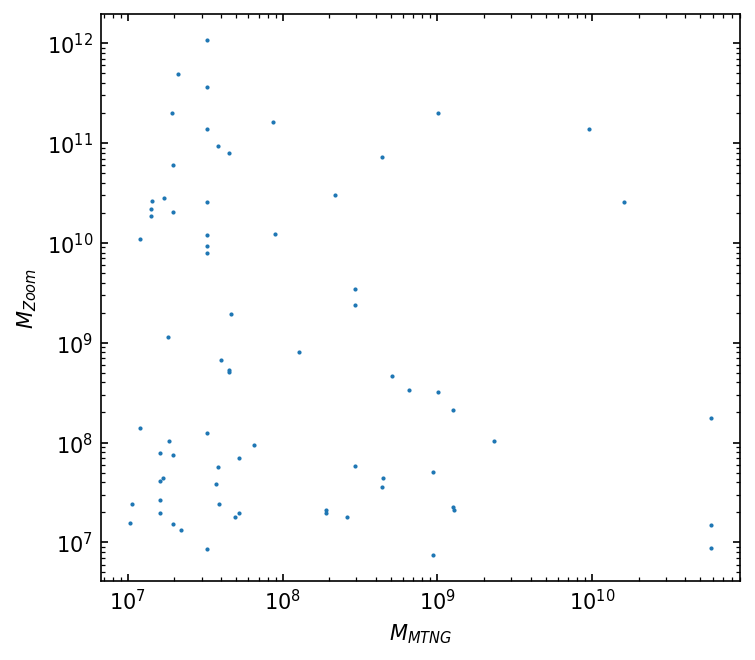

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(m_sub_mtng, m_sub_zoom, marker='o', ls='', ms=1)

ax.set_xlabel('$M_{MTNG}$')
ax.set_ylabel('$M_{Zoom}$')

### Cross-match FoF groups in the two

In [ ]:
zoom_sel = np.where(zoom.fof['halo_m200b']!=0)
mtng_sel = np.where(mtng.fof['halo_m200b']!=0)

In [ ]:
dist, ind = bacco.utils.crossmatch(zoom.fof['halo_pos'][zoom_sel], mtng.fof['halo_pos'][mtng_sel], max_distance=0.1, boxsize=500.000001)

In [ ]:
# clean the 
i_clean = np.where(dist!=np.inf)

In [ ]:
m_zoom = 1e10 * zoom.fof['halo_m200b'][zoom_sel][i_clean]
m_mtng = 1e10 * mtng.fof['halo_m200b'][mtng_sel][ind[i_clean]]

Text(0, 0.5, '$M_{Zoom}$')

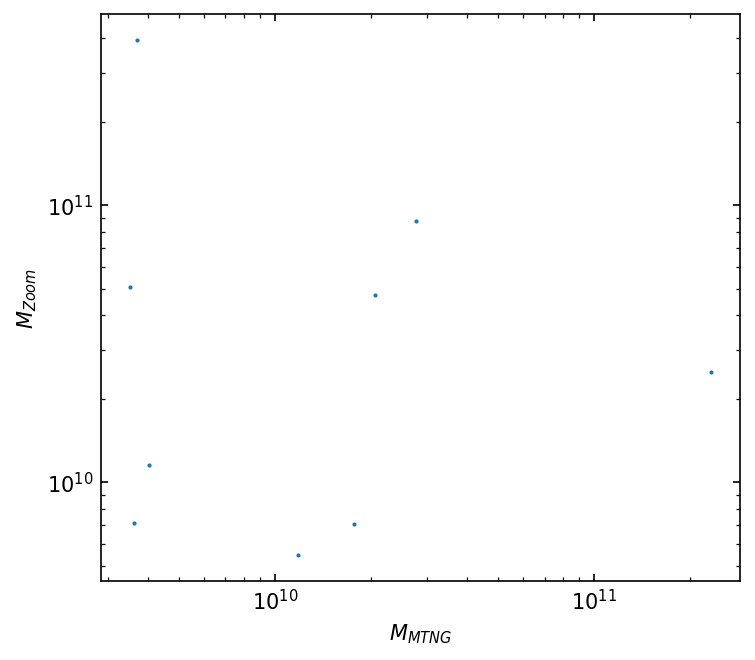

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(m_mtng, m_zoom, marker='o', ls='', ms=1)

ax.set_xlabel('$M_{MTNG}$')
ax.set_ylabel('$M_{Zoom}$')

In [39]:
dumps = np.array([-i*4*0.0081 for i in range(43)])

In [50]:
np.exp(dumps)

array([1.        , 0.96811926, 0.9372549 , 0.90737451, 0.87844674,
       0.8504412 , 0.82332851, 0.79708018, 0.77166867, 0.7470673 ,
       0.72325024, 0.70019249, 0.67786983, 0.65625884, 0.63533682,
       0.61508181, 0.59547254, 0.57648844, 0.55810956, 0.54031661,
       0.52309091, 0.50641439, 0.49026952, 0.47463936, 0.45950751,
       0.44485807, 0.43067566, 0.4169454 , 0.40365287, 0.39078412,
       0.37832563, 0.36626433, 0.35458755, 0.34328303, 0.33233892,
       0.3217437 , 0.31148628, 0.30155586, 0.29194204, 0.28263471,
       0.2736241 , 0.26490076, 0.25645553, 0.24827954])

In [51]:
z_dump =  1/np.exp(dumps) - 1

In [52]:
z_dump

array([0.        , 0.03293059, 0.06694561, 0.10208077, 0.13837294,
       0.17586024, 0.21458202, 0.25457893, 0.29589296, 0.33856748,
       0.38264731, 0.42817871, 0.47520948, 0.52378901, 0.57396828,
       0.6258    , 0.67933856, 0.73464018, 0.79176291, 0.85076673,
       0.91171358, 0.97466744, 1.03969441, 1.10686277, 1.17624301,
       1.24790799, 1.32193293, 1.39839557, 1.47737616, 1.55895763,
       1.64322563, 1.73026862, 1.82017799, 1.91304813, 2.00897654,
       2.10806392, 2.21041432, 2.31613517, 2.42533748, 2.53813588,
       2.6546488 , 2.77499856, 2.8993115 , 3.02771815])

In [48]:
dumps_2 = np.array([-42*4*0.0081 - 0.0162*4*i for i in range(15)])

In [46]:
z_dump_2 =  1/np.exp(dumps_2) - 1

In [47]:
z_dump_2

array([2.8993115 , 3.16035331, 3.43887071, 3.73603364, 4.05309032,
       4.39137255, 4.7523013 , 5.13739264, 5.54826415, 5.98664172,
       6.45436674, 6.9534039 , 7.4858494 , 8.0539398 , 8.66006136,
       9.3067601 , 9.99675248])

In [61]:
expfac = np.zeros(265)

for i in range(265):
    with h5py.File("/cosmos_storage/simulations/MTNG/single_files/file1/fof_subhalo_tab_{:03d}.1.hdf5".format(i)) as f:
        expfac[i] = f['Header'].attrs['Time']

In [98]:
with open("/cosmos_storage/home/fgmaion/MTNG_resims_snaps.txt", 'w') as f:
    for i in range(len(expfac[::5])):
        f.write(str(expfac[::5][i])+"\n")

In [78]:
1 / ( 1 + 1.5)

0.4

In [99]:
expfac

array([0.03298891, 0.03407837, 0.0352038 , 0.0363664 , 0.0375674 ,
       0.03880806, 0.04008969, 0.04141365, 0.04278133, 0.04419417,
       0.04565368, 0.04716139, 0.04871889, 0.05032782, 0.05198989,
       0.05370685, 0.05548052, 0.05731275, 0.0592055 , 0.06116075,
       0.06318058, 0.06526711, 0.06742255, 0.06964917, 0.07194933,
       0.07432544, 0.07678003, 0.07931568, 0.08193508, 0.08464097,
       0.08743623, 0.0903238 , 0.09180315, 0.09330673, 0.09483494,
       0.09638818, 0.09796685, 0.09957138, 0.1012022 , 0.10285972,
       0.10454439, 0.10625665, 0.10799695, 0.10976576, 0.11156354,
       0.11339076, 0.11524791, 0.11713548, 0.11905396, 0.12100386,
       0.1229857 , 0.125     , 0.12704729, 0.12912811, 0.13124301,
       0.13339255, 0.1355773 , 0.13779782, 0.14005472, 0.14234858,
       0.14468001, 0.14704962, 0.14945805, 0.15190592, 0.15439388,
       0.15692259, 0.15949272, 0.16210494, 0.16475995, 0.16745844,
       0.17020113, 0.17298874, 0.175822  , 0.17870167, 0.18162

In [176]:
import numpy as np

dlog1 = 0.0081
dlog2 = 0.0162
dlog3 = 0.0325

alist1 = [ np.exp(-dlog1 * i) for i in range(171) ]
alist2 = [ np.exp(-dlog1 * 171 - dlog2 * i) for i in range(62)]
alist3 = [ np.exp(-dlog1 * 171 - dlog2 * 62 - dlog3 * i) for i in range(32)]

In [177]:
alist = np.concatenate((alist1, alist2, alist3))

In [178]:
alist

array([1.        , 0.99193272, 0.98393051, 0.97599287, 0.96811926,
       0.96030916, 0.95256208, 0.94487749, 0.9372549 , 0.92969379,
       0.92219369, 0.91475409, 0.90737451, 0.90005447, 0.89279347,
       0.88559105, 0.87844674, 0.87136006, 0.86433055, 0.85735775,
       0.8504412 , 0.84358045, 0.83677505, 0.83002455, 0.82332851,
       0.81668648, 0.81009804, 0.80356275, 0.79708018, 0.79064991,
       0.78427151, 0.77794457, 0.77166867, 0.7654434 , 0.75926836,
       0.75314312, 0.7470673 , 0.7410405 , 0.73506232, 0.72913236,
       0.72325024, 0.71741558, 0.71162798, 0.70588708, 0.70019249,
       0.69454384, 0.68894075, 0.68338287, 0.67786983, 0.67240126,
       0.66697681, 0.66159612, 0.65625884, 0.65096461, 0.64571309,
       0.64050394, 0.63533682, 0.63021137, 0.62512728, 0.6200842 ,
       0.61508181, 0.61011977, 0.60519776, 0.60031546, 0.59547254,
       0.5906687 , 0.5859036 , 0.58117695, 0.57648844, 0.57183774,
       0.56722456, 0.5626486 , 0.55810956, 0.55360713, 0.54914